# 🎮 StratArena — LLM Training & Evaluation Notebook

**Pipeline overview:**
1. Explore the rollout dataset
2. Simulate baseline (untrained) LLM predictions
3. Run SFT training with Unsloth
4. Optionally run GRPO (RL) fine-tuning
5. Evaluate trained vs untrained model
6. Visualise all comparisons with rich plots

> **Colab workflow:** Upload `stratarena_rollouts.jsonl` , then run all cells top-to-bottom.

---
## 0 · Environment Setup

In [1]:
import subprocess, sys

def pip_install_command(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

# Core ML stack
pip_install_command('torch', '--index-url', 'https://download.pytorch.org/whl/cu121')
# Explicitly install transformers to a known compatible version to avoid conflicts
pip_install_command('transformers==4.36.2') # Pin transformers version for better Unsloth compatibility
pip_install_command('datasets', 'trl>=0.8', 'accelerate', 'bitsandbytes', 'peft')

# Unsloth for fast fine-tuning (Colab-compatible)
# Install unsloth after transformers is pinned
pip_install_command('unsloth[colab-new]')

# Plotting
pip_install_command('matplotlib', 'seaborn', 'pandas', 'numpy', 'scikit-learn')

print('✅ All packages installed.')

✅ All packages installed.


In [ ]:
import json, re, random, warnings
from pathlib import Path
from collections import defaultdict
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
COLORS = {'untrained': '#e74c3c', 'sft': '#3498db', 'grpo': '#2ecc71', 'heuristic': '#f39c12'}

# ── Paths ─────────────────────────────────────────────────────────────────────
DATASET_PATH = '/content/stratarena_rollouts.jsonl'
SFT_OUTPUT   = 'outputs/stratarena_sft'
GRPO_OUTPUT  = 'outputs/stratarena_grpo'
BASE_MODEL   = 'meta-llama/Llama-3.2-1B-Instruct'

print('✅ Imports OK.')

✅ Imports OK.


---
## 1 · Dataset Exploration

In [11]:
# ── Load rollouts ─────────────────────────────────────────────────────────────
def load_rollout_rows(path: str) -> list[dict]:
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

rows = load_rollout_rows(DATASET_PATH)
df   = pd.DataFrame(rows)

# Parse prompt JSON into columns
prompt_data = df['prompt'].apply(json.loads)
df['resource_value']    = prompt_data.apply(lambda x: x.get('resource_value', 0))
df['market_pressure']   = prompt_data.apply(lambda x: x.get('market_pressure', 0))
df['budget_ratio']      = prompt_data.apply(lambda x: x.get('budget_ratio', 0))
df['uncertainty_signal']= prompt_data.apply(lambda x: x.get('uncertainty_signal', 0))
df['exploit_signal']    = prompt_data.apply(lambda x: x.get('exploit_signal', 0))

# Parse allocation from completion
def extract_allocation(text):
    m = re.search(r'"allocation"\s*:\s*([0-9]+(?:\.[0-9]+)?)', str(text))
    return float(m.group(1)) if m else None

df['allocation'] = df['completion'].apply(extract_allocation)
df['policy']     = df['metadata'].apply(lambda x: x.get('policy', 'unknown'))

print(f'Loaded {len(df)} steps across {df.groupby(["task","episode_seed"]).ngroups} episodes')
print(df[['task','step','allocation','reward','task_score','winner']].head(8).to_string())

Loaded 15784 steps across 600 episodes
   task  step  allocation  reward  task_score      winner
0  easy     0      0.0000  1.5038      0.0000  aggressive
1  easy     1      0.6500  0.0000      0.0000  aggressive
2  easy     2      0.6500  0.0000      0.0000  aggressive
3  easy     3      0.6500  0.0000      0.0000  aggressive
4  easy     4      0.5603  0.0000      0.0000  aggressive
5  easy     5      0.6500  0.0000      0.0000  aggressive
6  easy     6      1.2000 -0.0743      0.0000  aggressive
7  easy     7      1.2000  9.7423      0.3166          me


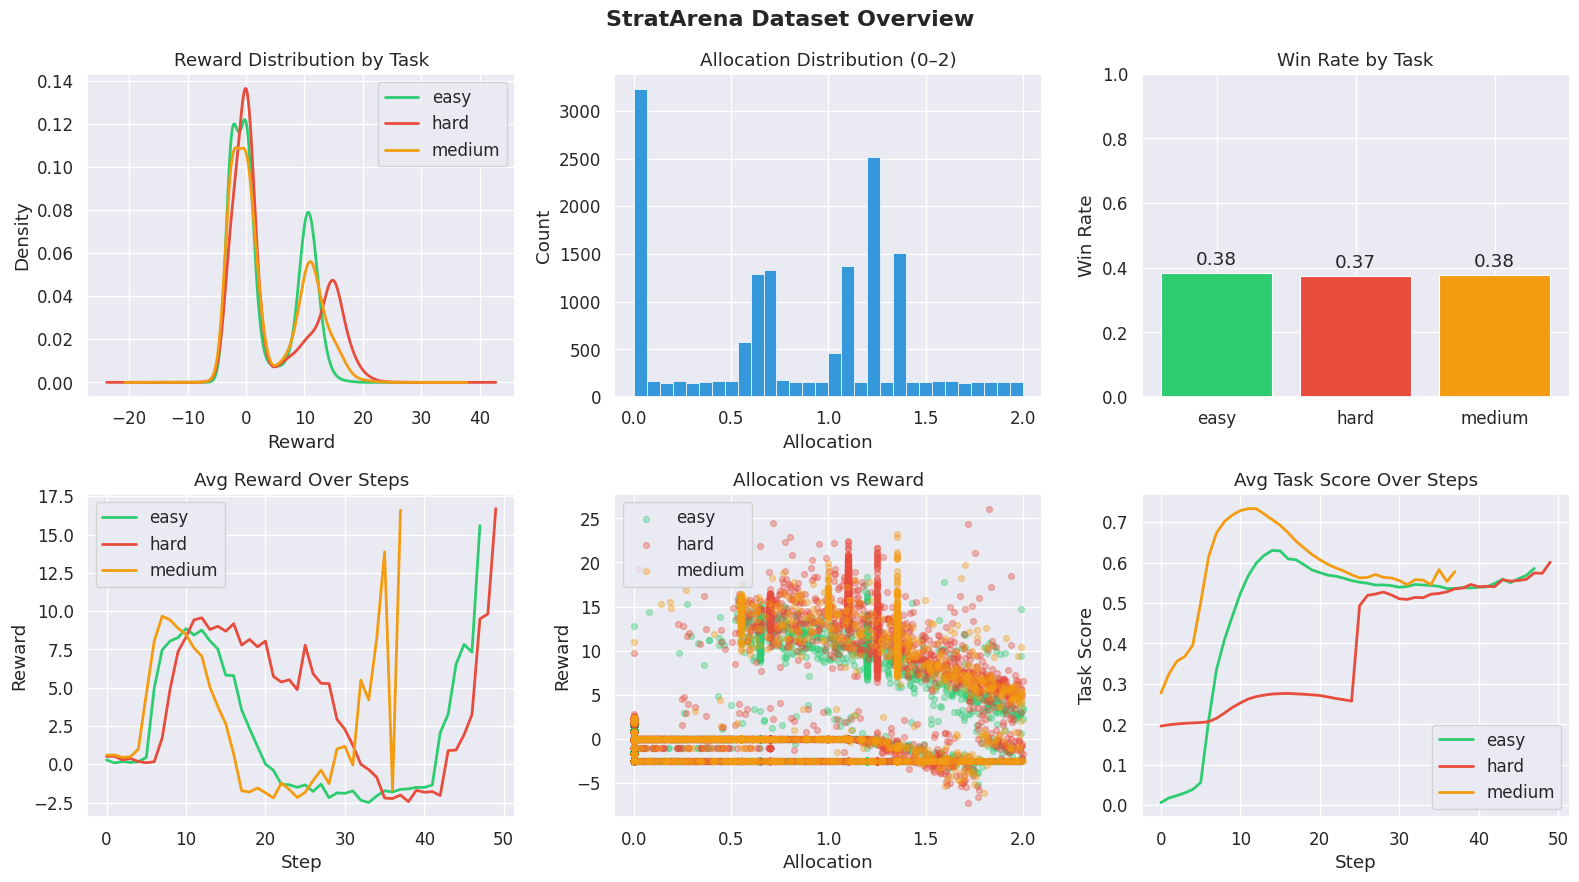

Fig 1 saved → dataset_overview.png


In [12]:
# ── Fig 1: Dataset Overview ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('StratArena Dataset Overview', fontsize=16, fontweight='bold')

task_colors = {'easy': '#2ecc71', 'medium': '#f39c12', 'hard': '#e74c3c'}

# 1a – Reward distribution by task
ax = axes[0, 0]
for task, grp in df.groupby('task'):
    grp['reward'].plot.kde(ax=ax, label=task, color=task_colors[task], linewidth=2)
ax.set_title('Reward Distribution by Task')
ax.set_xlabel('Reward'); ax.legend()

# 1b – Allocation distribution
ax = axes[0, 1]
df['allocation'].dropna().hist(ax=ax, bins=30, color='#3498db', edgecolor='white', linewidth=0.5)
ax.set_title('Allocation Distribution (0–2)')
ax.set_xlabel('Allocation'); ax.set_ylabel('Count')

# 1c – Win rate by task
ax = axes[0, 2]
win_rates = df.groupby('task').apply(lambda g: (g['winner'] == 'me').mean()).reset_index()
win_rates.columns = ['task', 'win_rate']
bars = ax.bar(win_rates['task'], win_rates['win_rate'],
              color=[task_colors[t] for t in win_rates['task']], edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_ylim(0, 1); ax.set_title('Win Rate by Task'); ax.set_ylabel('Win Rate')

# 1d – Reward over steps
ax = axes[1, 0]
for task, grp in df.groupby('task'):
    avg_r = grp.groupby('step')['reward'].mean()
    ax.plot(avg_r.index, avg_r.values, label=task, color=task_colors[task], linewidth=2)
ax.set_title('Avg Reward Over Steps'); ax.set_xlabel('Step'); ax.set_ylabel('Reward'); ax.legend()

# 1e – Allocation vs Reward scatter
ax = axes[1, 1]
for task, grp in df.groupby('task'):
    ax.scatter(grp['allocation'], grp['reward'], alpha=0.35, s=18,
               label=task, color=task_colors[task])
ax.set_title('Allocation vs Reward'); ax.set_xlabel('Allocation'); ax.set_ylabel('Reward'); ax.legend()

# 1f – Task score progression
ax = axes[1, 2]
for task, grp in df.groupby('task'):
    avg_ts = grp.groupby('step')['task_score'].mean()
    ax.plot(avg_ts.index, avg_ts.values, label=task, color=task_colors[task], linewidth=2)
ax.set_title('Avg Task Score Over Steps'); ax.set_xlabel('Step'); ax.set_ylabel('Task Score'); ax.legend()

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 1 saved → dataset_overview.png')

---
## 2 · Training Utilities

All helper functions from `unsloth_colab_train.py`, inlined and extended.

In [13]:
# ── System prompt (matches unsloth_colab_train.py) ────────────────────────────
SYSTEM_PROMPT = """You are the learner policy for StratArena.
You receive a partial-observability game state.
Return only JSON with this schema:
{"allocation": <float 0-2>, "reason": "<short phrase>"}
Pick stronger allocations only when value is strong or an opponent looks weak.
Reduce allocation when pressure or uncertainty is high."""


def build_sft_records(rows):
    return [
        {
            'prompt': [
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user',   'content': row['prompt']},
            ],
            'completion': row['completion'],
            'task':       row['task'],
            'reward':     row['reward'],
            'task_score': row['task_score'],
        }
        for row in rows
    ]


def build_grpo_records(rows):
    return [
        {
            'prompt': [
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user',   'content': row['prompt']},
            ],
            'task':            row['task'],
            'reference_reward':row['reward'],
            'reference_score': row['task_score'],
            'metadata':        row.get('metadata', {}),
        }
        for row in rows
    ]


def _extract_allocation(text: str) -> float | None:
    if not text:
        return None
    m = re.search(r'"allocation"\s*:\s*([0-9]+(?:\.[0-9]+)?)', text)
    if not m:
        return None
    try:
        return max(0.0, min(2.0, float(m.group(1))))
    except ValueError:
        return None


def _parse_completion_text(item: Any) -> str:
    if isinstance(item, str):
        return item
    if isinstance(item, list):
        parts = []
        for chunk in item:
            if isinstance(chunk, dict):
                parts.append(str(chunk.get('text', chunk.get('content', ''))))
            else:
                parts.append(str(chunk))
        return ''.join(parts)
    if isinstance(item, dict):
        return str(item.get('content', item))
    return str(item)


sft_records  = build_sft_records(rows)
grpo_records = build_grpo_records(rows)
print(f'SFT records: {len(sft_records)}  |  GRPO records: {len(grpo_records)}')

SFT records: 15784  |  GRPO records: 15784


In [14]:
# ── Reward functions (GRPO) ───────────────────────────────────────────────────

def format_reward_func(completions, **kwargs) -> list[float]:
    """Structural reward: +0.2 if allocation is parseable, -1.0 otherwise."""
    rewards = []
    for c in completions:
        text = _parse_completion_text(c)
        rewards.append(0.2 if _extract_allocation(text) is not None else -1.0)
    return rewards


def simulated_env_reward(allocation: float, obs: dict) -> float:
    """
    Lightweight reward simulation (no live StratArena env required).
    Mirrors the logic in unsloth_colab_train.py::strat_arena_reward_func.
    """
    resource_value  = obs.get('resource_value', 50.0)
    market_pressure = obs.get('market_pressure', 1.0)
    uncertainty     = obs.get('uncertainty_signal', 0.5)
    exploit         = obs.get('exploit_signal', 0.0)

    # Normalise value
    value_norm = resource_value / 100.0

    # Heuristic: bid proportional to value, tempered by pressure & uncertainty
    ideal_bid = value_norm * (1.0 - 0.3 * uncertainty) * min(1.5, market_pressure)
    ideal_bid = max(0.0, min(2.0, ideal_bid))

    # Reward = 1 - normalised distance to ideal, plus exploit bonus
    dist   = abs(allocation - ideal_bid) / 2.0
    reward = max(-1.0, 1.0 - 2.0 * dist) + 0.3 * exploit * (allocation > 0.8)
    return float(reward)


print('✅ Reward functions defined.')

✅ Reward functions defined.


---
## 3 · Baseline: Untrained LLM Predictions

In [15]:
# ── Load base model (no training) ────────────────────────────────────────────
from unsloth import FastLanguageModel
import torch

MAX_SEQ_LENGTH = 1024

base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
)
FastLanguageModel.for_inference(base_model)
print(f'✅ Loaded: {BASE_MODEL}')

==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.10G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Unsloth: Will load unsloth/llama-3.2-1b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


✅ Loaded: meta-llama/Llama-3.2-1B-Instruct


In [16]:
# ── Generate predictions from a model ────────────────────────────────────────
def generate_predictions(model, tokenizer, sample_rows: list[dict],
                          max_new_tokens: int = 80) -> list[dict]:
    """Run inference on a list of rollout rows; return enriched dicts."""
    results = []
    model.eval()
    with torch.no_grad():
        for row in sample_rows:
            messages = [
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user',   'content': row['prompt']},
            ]
            text  = tokenizer.apply_chat_template(messages, tokenize=False,
                                                   add_generation_prompt=True)
            inputs = tokenizer(text, return_tensors='pt',
                               truncation=True, max_length=MAX_SEQ_LENGTH).to(model.device)
            output = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                temperature=1.0,
                pad_token_id=tokenizer.eos_token_id,
            )
            generated = tokenizer.decode(
                output[0][inputs['input_ids'].shape[-1]:], skip_special_tokens=True
            )
            allocation = _extract_allocation(generated)
            obs        = json.loads(row['prompt'])
            env_reward = simulated_env_reward(allocation or 0.0, obs)
            results.append({
                'task':             row['task'],
                'step':             row['step'],
                'raw_output':       generated,
                'predicted_alloc':  allocation,
                'reference_alloc':  _extract_allocation(row['completion']),
                'reference_reward': row['reward'],
                'simulated_reward': env_reward,
                'format_ok':        allocation is not None,
            })
    return results


# Use up to 60 evenly-spread samples so Colab stays fast
sample_rows = rows[::max(1, len(rows)//60)][:60]
print(f'Evaluating on {len(sample_rows)} samples…')
untrained_results = generate_predictions(base_model, base_tokenizer, sample_rows)
untrained_df = pd.DataFrame(untrained_results)

fmt_rate   = untrained_df['format_ok'].mean()
avg_reward = untrained_df['simulated_reward'].mean()
print(f'Untrained  →  format-OK: {fmt_rate:.1%}  |  avg sim-reward: {avg_reward:.3f}')

Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Evaluating on 60 samples…


Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Untrained  →  format-OK: 100.0%  |  avg sim-reward: 0.638


In [17]:
# ═══════════════════════════════════════════════════════════════════
# BEFORE TRAINING — Collect untrained model predictions
# Run this cell RIGHT AFTER loading base_model in Section 3
# ═══════════════════════════════════════════════════════════════════
import torch, json, re
from tqdm import tqdm

EVAL_SAMPLES = sample_rows   # 60 evenly-spaced rows from the dataset

def run_inference(model, tokenizer, eval_rows, label):
    """Generate allocations and compute simulated rewards for one model."""
    model.eval()
    results = []
    with torch.no_grad():
        for row in tqdm(eval_rows, desc=f'Inferring [{label}]'):
            obs = json.loads(row['prompt'])
            messages = [
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user',   'content': row['prompt']},
            ]
            text   = tokenizer.apply_chat_template(messages, tokenize=False,
                                                    add_generation_prompt=True)
            inputs = tokenizer(text, return_tensors='pt',
                               truncation=True, max_length=1024).to(model.device)
            out    = model.generate(
                **inputs, max_new_tokens=80, do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
            generated  = tokenizer.decode(out[0][inputs['input_ids'].shape[-1]:],
                                          skip_special_tokens=True)
            pred_alloc = _extract_allocation(generated)
            ref_alloc  = _extract_allocation(row['completion'])
            sim_reward = simulated_env_reward(pred_alloc or 0.0, obs)

            results.append({
                'model':           label,
                'task':            row['task'],
                'step':            row['step'],
                'pred_alloc':      pred_alloc,
                'ref_alloc':       ref_alloc,
                'ref_reward':      row['reward'],        # expert reward from dataset
                'sim_reward':      sim_reward,
                'format_ok':       pred_alloc is not None,
                'alloc_error':     abs((pred_alloc or 0.0) - (ref_alloc or 0.0)),
                'raw_output':      generated,
            })
    return results

# ── Capture untrained results ─────────────────────────────────────
pretrain_results = run_inference(base_model, base_tokenizer, EVAL_SAMPLES, 'Before Training')
pretrain_df      = pd.DataFrame(pretrain_results)

print(f"\n{'─'*50}")
print(f"  BEFORE TRAINING  ({BASE_MODEL})")
print(f"{'─'*50}")
print(f"  Format OK      : {pretrain_df['format_ok'].mean():.1%}")
print(f"  Avg Sim Reward : {pretrain_df['sim_reward'].mean():.4f}")
print(f"  Avg Alloc Error: {pretrain_df['alloc_error'].mean():.4f}")
print(f"{'─'*50}")

Inferring [Before Training]: 100%|██████████| 60/60 [00:42<00:00,  1.41it/s]


──────────────────────────────────────────────────
  BEFORE TRAINING  (meta-llama/Llama-3.2-1B-Instruct)
──────────────────────────────────────────────────
  Format OK      : 100.0%
  Avg Sim Reward : 0.6383
  Avg Alloc Error: 0.5421
──────────────────────────────────────────────────


---
## 4 · SFT Training

In [18]:
# ── Build dataset ─────────────────────────────────────────────────────────────
from datasets import Dataset
from transformers import TrainingArguments
from trl import SFTTrainer

sft_dataset = Dataset.from_list(sft_records)
print(f'SFT dataset size: {len(sft_dataset)}')

SFT dataset size: 15784


In [19]:
# ── Add LoRA adapters ─────────────────────────────────────────────────────────
sft_model = FastLanguageModel.get_peft_model(
    base_model,
    r=16,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj',
                    'gate_proj', 'up_proj', 'down_proj'],
    lora_alpha=16,
    lora_dropout=0.0,
    bias='none',
    use_gradient_checkpointing='unsloth',
    random_state=3407,
    max_seq_length=MAX_SEQ_LENGTH,
)
print('✅ LoRA adapters attached.')

Unsloth 2026.4.8 patched 16 layers with 16 QKV layers, 16 O layers and 16 MLP layers.


✅ LoRA adapters attached.


In [20]:
# ── SFT trainer ───────────────────────────────────────────────────────────────
sft_log_history = []

from transformers import TrainerCallback
from trl import SFTConfig  # use SFTConfig instead of TrainingArguments

class LogCapture(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and 'loss' in logs:
            sft_log_history.append({'step': state.global_step, 'loss': logs['loss']})


# Define the formatting function for SFTTrainer
def formatting_func(examples):
    output_texts = []
    # Iterate over the lists of prompts and completions in the batch
    for prompt_messages, completion_text in zip(examples['prompt'], examples['completion']):
        # Apply chat template to the prompt, including add_generation_prompt
        chat_formatted_prompt = base_tokenizer.apply_chat_template(
            prompt_messages, tokenize=False, add_generation_prompt=True
        )
        # Concatenate with the completion
        full_text = chat_formatted_prompt + completion_text
        output_texts.append(full_text)
    return {'text': output_texts} # Return a dictionary with 'text' key

# Pre-process the dataset to create the 'text' column
sft_dataset = sft_dataset.map(formatting_func, batched=True, remove_columns=sft_dataset.column_names)

sft_trainer = SFTTrainer(
    model=sft_model,
    tokenizer=base_tokenizer,
    train_dataset=sft_dataset, # Use the pre-processed sft_dataset
    # formatting_func=formatting_func, # No longer needed here as dataset is pre-formatted
    dataset_text_field='text',        # Point to the 'text' key returned by formatting_func
    callbacks=[LogCapture()],
    args=SFTConfig(                   # SFTConfig instead of TrainingArguments
        output_dir=SFT_OUTPUT,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        learning_rate=2e-4,
        num_train_epochs=1,
        logging_steps=5,
        save_steps=100,
        fp16=True,
        bf16=False,
        optim='adamw_8bit',
        report_to='none',
        completion_only_loss=False,   # sits in SFTConfig, not TrainingArguments
    ),
)

print('Starting SFT…')
sft_trainer.train()
sft_trainer.save_model(SFT_OUTPUT)
base_tokenizer.save_pretrained(SFT_OUTPUT)
print(f'✅ SFT done. Model saved → {SFT_OUTPUT}')

Map:   0%|          | 0/15784 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/15784 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Starting SFT…


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 15,784 | Num Epochs = 1 | Total steps = 1,973
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 11,272,192 of 1,247,086,592 (0.90% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
5,2.499388
10,2.471091
15,2.396127
20,2.288764
25,2.155220
30,2.050799
35,1.930201
40,1.750669
45,1.520324
50,1.279206


Unsloth: Restored added_tokens_decoder metadata in outputs/stratarena_sft/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/stratarena_sft/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/stratarena_sft/checkpoint-300/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/stratarena_sft/checkpoint-400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/stratarena_sft/checkpoint-500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/stratarena_sft/checkpoint-600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/stratarena_sft/checkpoint-700/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/stratarena_sft/checkpoint-800/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/stratarena_sft/checkpoint-900/tokenizer_confi

✅ SFT done. Model saved → outputs/stratarena_sft


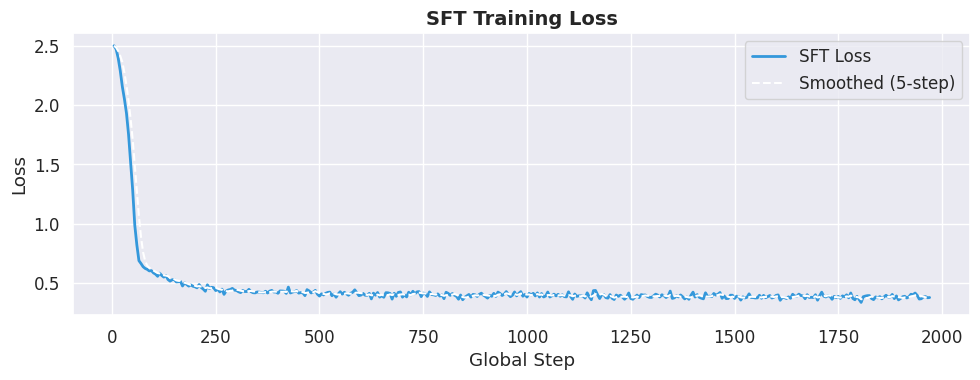

Fig 2 saved → sft_loss.png


In [21]:
# ── Fig 2: SFT Training Loss ──────────────────────────────────────────────────
loss_df = pd.DataFrame(sft_log_history)

fig, ax = plt.subplots(figsize=(10, 4))

if not loss_df.empty:
    ax.plot(loss_df['step'], loss_df['loss'], color=COLORS['sft'], linewidth=2, label='SFT Loss')

    if len(loss_df) >= 5:
        ax.plot(loss_df['step'], loss_df['loss'].rolling(5, min_periods=1).mean(),
                color='white', linewidth=1.5, linestyle='--', label='Smoothed (5-step)')
    ax.set_title('SFT Training Loss', fontsize=14, fontweight='bold')
    ax.set_xlabel('Global Step'); ax.set_ylabel('Loss'); ax.legend()
    plt.tight_layout()
    plt.savefig('sft_loss.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Fig 2 saved → sft_loss.png')
else:
    print('No SFT training loss data available to plot.')
    print('This might indicate an issue with the LogCapture callback or training configuration.')



---
## 5 · GRPO (RL) Training

In [22]:
# ── GRPO reward functions ─────────────────────────────────────────────────────
def grpo_format_reward(completions, **kwargs) -> list[float]:
    return format_reward_func(completions, **kwargs)


def grpo_env_reward(prompts, completions, task, **kwargs) -> list[float]:
    """Simulated environment reward (no live StratArena server needed)."""
    rewards = []
    for prompt_msgs, completion, task_name in zip(prompts, completions, task):
        user_content = prompt_msgs[-1]['content']
        text = _parse_completion_text(completion)
        allocation = _extract_allocation(text)
        if allocation is None:
            rewards.append(-2.0); continue
        try:
            obs = json.loads(user_content)
        except json.JSONDecodeError:
            rewards.append(-1.5); continue
        env_r = simulated_env_reward(allocation, obs)
        rewards.append(env_r)
    return rewards


print('✅ GRPO reward functions ready.')

✅ GRPO reward functions ready.


In [23]:
# ── GRPO trainer ──────────────────────────────────────────────────────────────
from trl import GRPOConfig, GRPOTrainer

# Load the SFT model and tokenizer to warm-start GRPO
grpo_model, grpo_tokenizer = FastLanguageModel.from_pretrained(
    model_name=SFT_OUTPUT, max_seq_length=MAX_SEQ_LENGTH, load_in_4bit=True
)

grpo_dataset = Dataset.from_list(grpo_records)
grpo_log_history = []

class GrpoLogCapture(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            entry = {'step': state.global_step}
            for k in ('reward', 'reward/format_reward_func',
                      'reward/grpo_env_reward', 'loss', 'kl'):
                if k in logs:
                    entry[k] = logs[k]
            if len(entry) > 1:
                grpo_log_history.append(entry)


grpo_trainer = GRPOTrainer(
    model=grpo_model,           # Use the loaded model object here
    tokenizer=grpo_tokenizer,
    reward_funcs=[grpo_format_reward, grpo_env_reward],
    train_dataset=grpo_dataset,
    callbacks=[GrpoLogCapture()],
    args=GRPOConfig(
        output_dir=GRPO_OUTPUT,
        learning_rate=5e-6,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        num_generations=4,
        max_prompt_length=1024,
        max_completion_length=96,
        max_steps=300,
        logging_steps=5,
        save_steps=50,
        report_to='none',
        bf16=False,
        fp16=True,
        use_vllm=False,
    ),
)

print('Starting GRPO…')
grpo_trainer.train()
grpo_trainer.save_model(GRPO_OUTPUT)
print(f'✅ GRPO done. Model saved → {GRPO_OUTPUT}')

==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-1b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


Starting GRPO…


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 15,784 | Num Epochs = 1 | Total steps = 300
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 11,272,192 of 1,247,086,592 (0.90% trained)
Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'cache_implementation', 'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=96) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / grpo_format_reward / mean,rewards / grpo_format_reward / std,rewards / grpo_env_reward / mean,rewards / grpo_env_reward / std
5,0.002057,0.791385,0.179702,12.950000,12.400000,13.200000,0.000000,12.950000,12.400000,13.200000,2.056960,0.200000,0.000000,0.591385,0.179702
10,0.002113,0.709319,0.181889,13.200000,12.600000,13.600000,0.000000,13.200000,12.600000,13.600000,2.112555,0.200000,0.000000,0.509319,0.181889
15,0.001909,0.742283,0.231030,13.150000,12.600000,13.600000,0.000000,13.150000,12.600000,13.600000,1.902965,0.200000,0.000000,0.542283,0.231030
20,0.002023,0.748255,0.170750,13.050000,12.600000,13.400000,0.000000,13.050000,12.600000,13.400000,2.022940,0.200000,0.000000,0.548255,0.170750
25,0.002028,0.803333,0.223700,12.900000,12.200000,13.400000,0.000000,12.900000,12.200000,13.400000,2.028300,0.200000,0.000000,0.603333,0.223700
30,0.001696,0.697809,0.206867,12.900000,12.200000,13.600000,0.000000,12.900000,12.200000,13.600000,1.695786,0.200000,0.000000,0.497809,0.206867
35,0.001615,0.599650,0.170896,13.000000,12.200000,13.800000,0.000000,13.000000,12.200000,13.800000,1.615387,0.200000,0.000000,0.399650,0.170896
40,0.001865,0.757437,0.113036,12.950000,12.200000,13.400000,0.000000,12.950000,12.200000,13.400000,1.864496,0.200000,0.000000,0.557437,0.113036
45,0.001958,0.785201,0.289068,13.150000,12.400000,13.600000,0.000000,13.150000,12.400000,13.600000,1.958310,0.200000,0.000000,0.585201,0.289068
50,0.002048,0.944644,0.153411,13.350000,12.600000,13.800000,0.000000,13.350000,12.600000,13.800000,2.048341,0.200000,0.000000,0.744644,0.153411


Both `max_new_tokens` (=96) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

✅ GRPO done. Model saved → outputs/stratarena_grpo


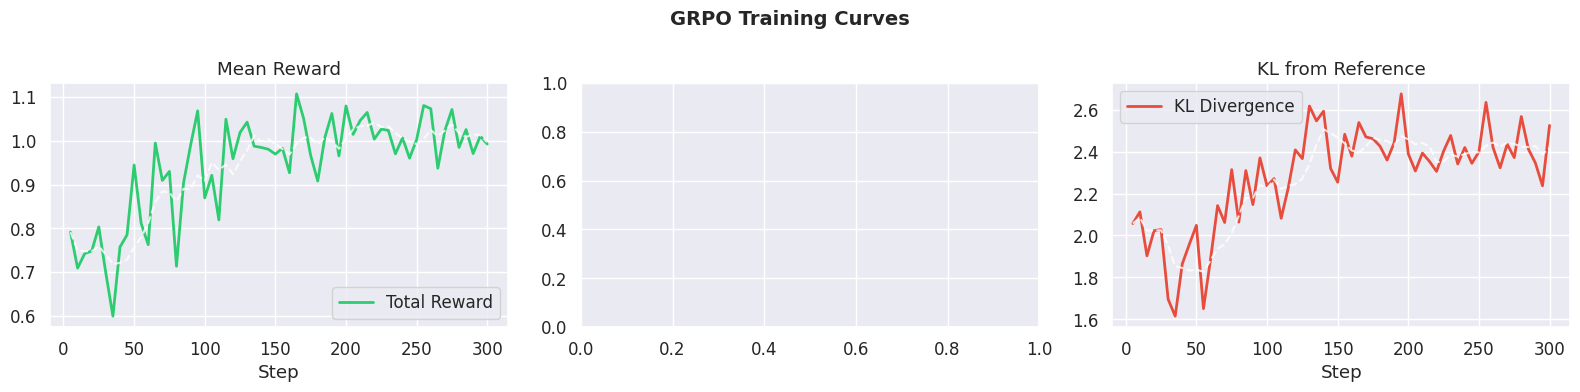

Fig 3 saved → grpo_curves.png


In [24]:
# ── Fig 3: GRPO Training Curves ───────────────────────────────────────────────
grpo_df = pd.DataFrame(grpo_log_history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('GRPO Training Curves', fontsize=14, fontweight='bold')

def safe_plot(ax, col, label, color, title):
    if col in grpo_df.columns:
        ax.plot(grpo_df['step'], grpo_df[col], color=color, linewidth=2, label=label)
        if len(grpo_df) >= 5:
            ax.plot(grpo_df['step'], grpo_df[col].rolling(5, min_periods=1).mean(),
                    color='white', linewidth=1.5, linestyle='--', alpha=0.8)
        ax.set_title(title); ax.set_xlabel('Step'); ax.legend()

safe_plot(axes[0], 'reward',                       'Total Reward',   COLORS['grpo'],    'Mean Reward')
safe_plot(axes[1], 'reward/grpo_env_reward',        'Env Reward',     COLORS['sft'],     'Env Reward')
safe_plot(axes[2], 'kl',                            'KL Divergence',  COLORS['untrained'],'KL from Reference')

plt.tight_layout()
plt.savefig('grpo_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 3 saved → grpo_curves.png')

==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-1b-instruct-unsloth-bnb-4bit as a legacy tokenizer.
Inferring [After Training (GRPO)]: 100%|██████████| 60/60 [00:30<00:00,  1.95it/s]



──────────────────────────────────────────────────
  AFTER TRAINING  (GRPO)
──────────────────────────────────────────────────
  Format OK      : 100.0%
  Avg Sim Reward : 0.8087
  Avg Alloc Error: 0.4173
──────────────────────────────────────────────────


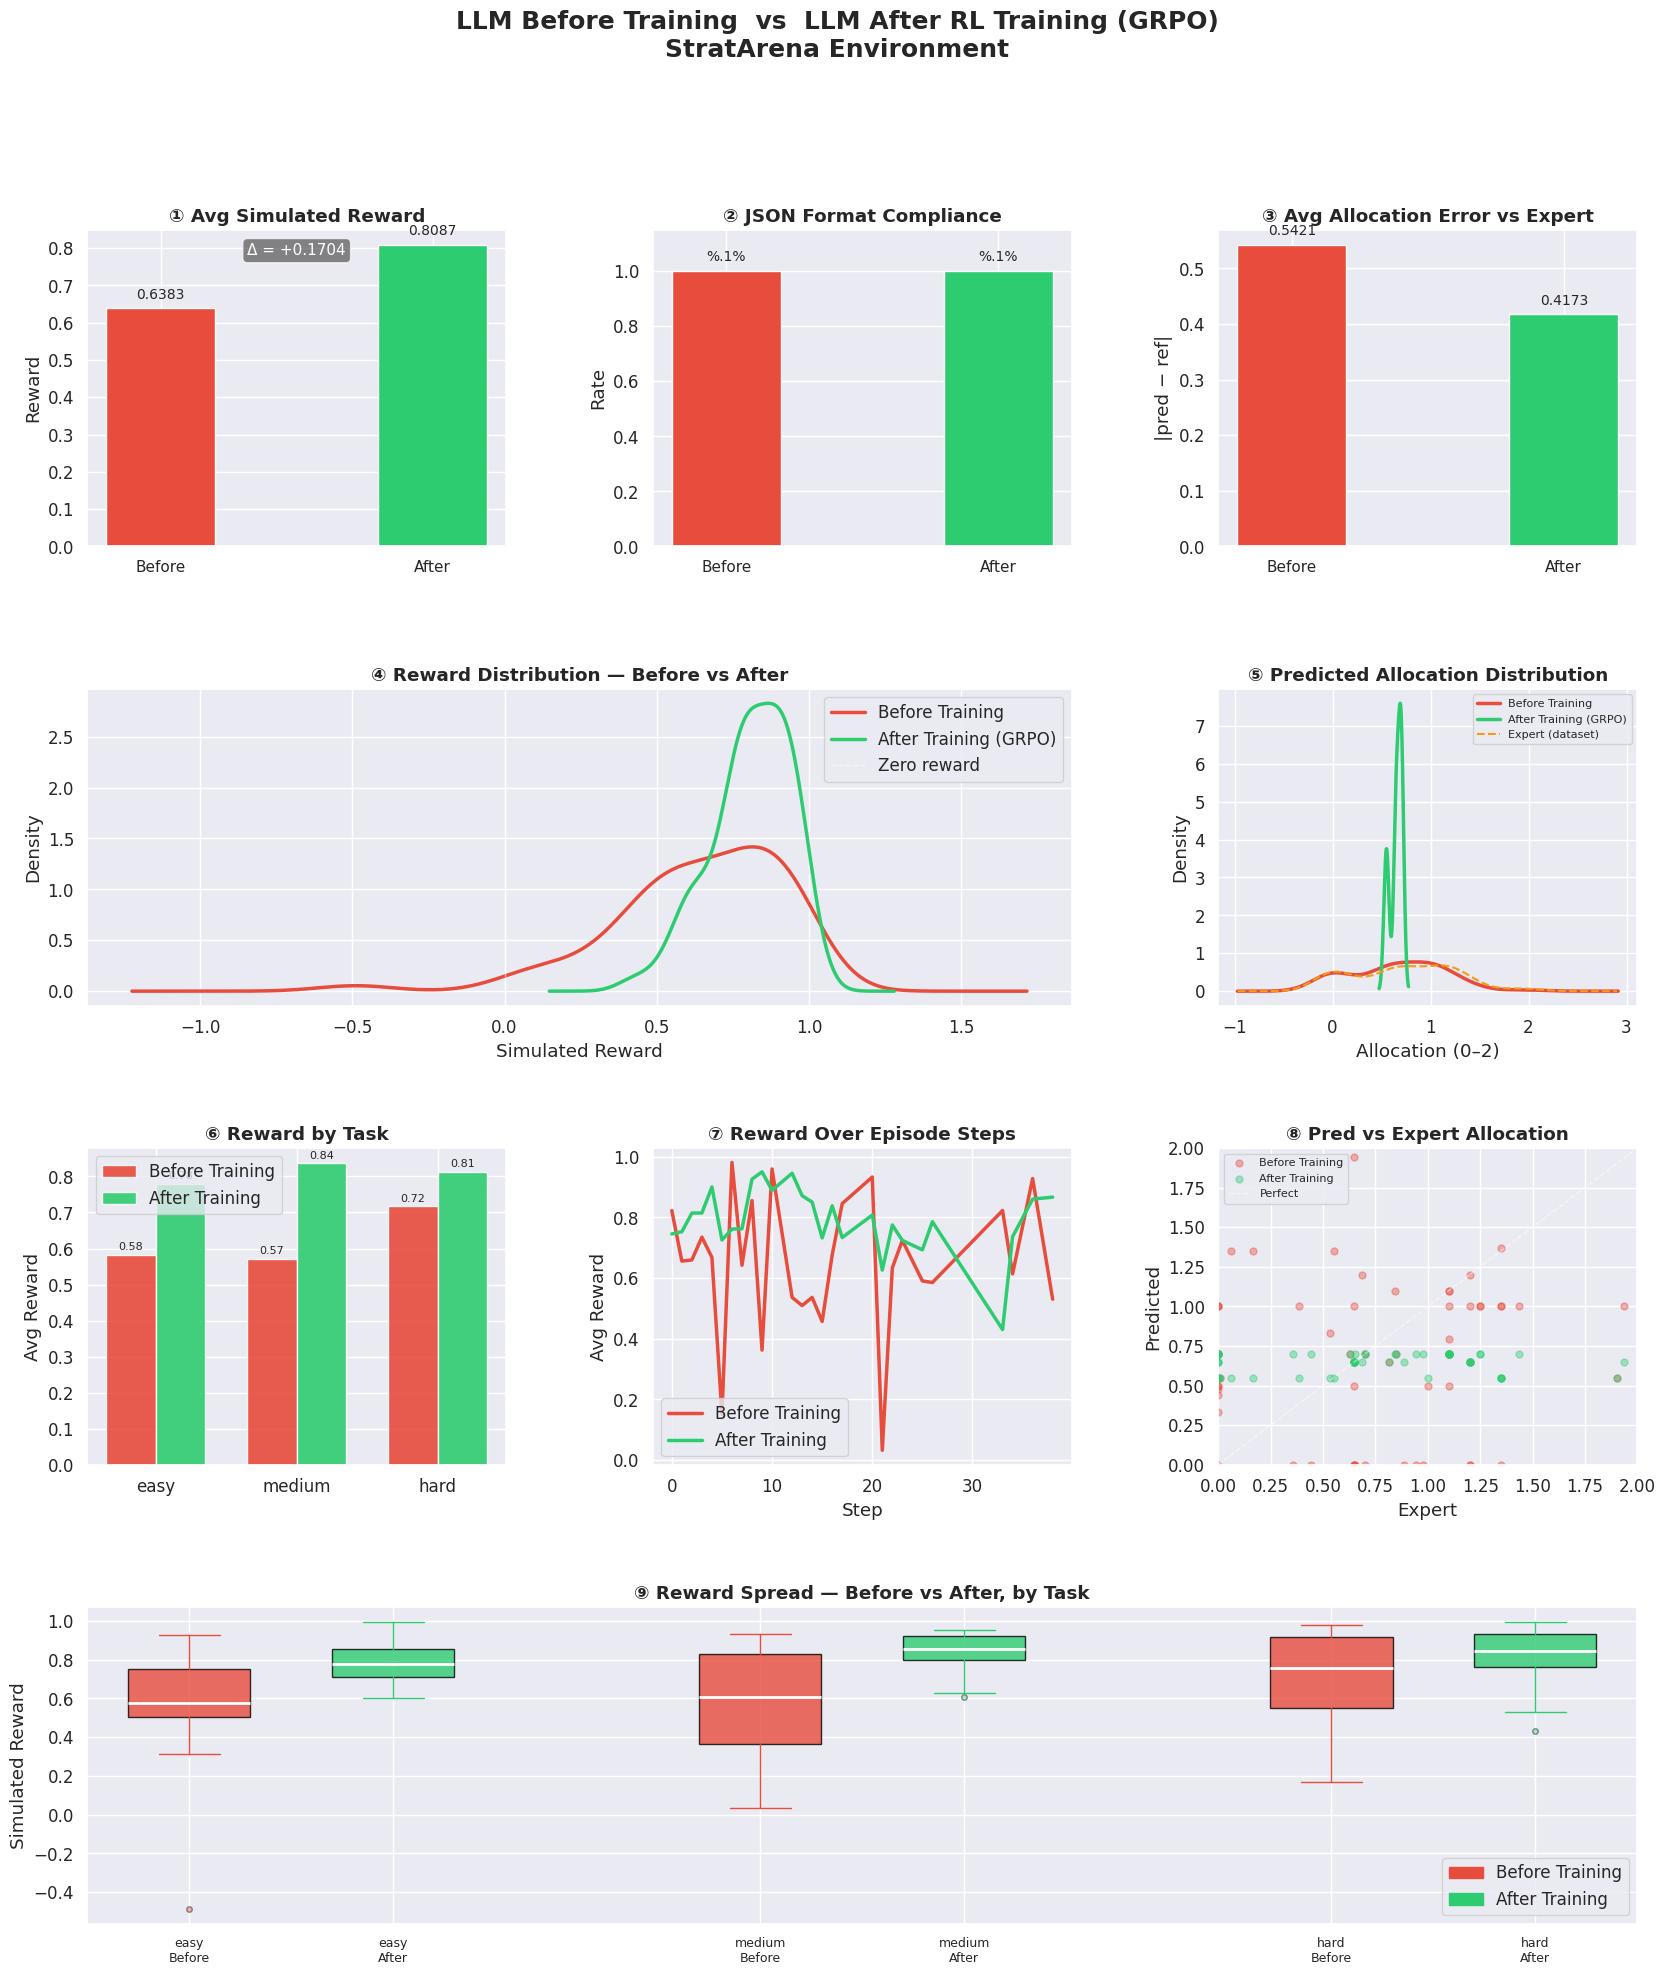


✅ Saved → before_vs_after_training.png

═══════════════════════════════════════════════════════
              FINAL BEFORE vs AFTER SUMMARY            
═══════════════════════════════════════════════════════
  BEFORE  |  Format: 100.0%  |  Reward: 0.6383  |  AllocErr: 0.5421
  AFTER   |  Format: 100.0%  |  Reward: 0.8087  |  AllocErr: 0.4173
───────────────────────────────────────────────────────
  📈 Reward improvement after RL training: +0.1704
═══════════════════════════════════════════════════════


In [25]:

# ── Load the GRPO-trained model ───────────────────────────────────
from unsloth import FastLanguageModel

trained_model, trained_tokenizer = FastLanguageModel.from_pretrained(
    model_name=GRPO_OUTPUT, max_seq_length=1024, load_in_4bit=True)
FastLanguageModel.for_inference(trained_model)

posttrain_results = run_inference(trained_model, trained_tokenizer, EVAL_SAMPLES, 'After Training (GRPO)')
posttrain_df      = pd.DataFrame(posttrain_results)

print(f"\n{'─'*50}")
print(f"  AFTER TRAINING  (GRPO)")
print(f"{'─'*50}")
print(f"  Format OK      : {posttrain_df['format_ok'].mean():.1%}")
print(f"  Avg Sim Reward : {posttrain_df['sim_reward'].mean():.4f}")
print(f"  Avg Alloc Error: {posttrain_df['alloc_error'].mean():.4f}")
print(f"{'─'*50}")


compare_df = pd.concat([pretrain_df, posttrain_df], ignore_index=True)

#  BEFORE vs AFTER — Comparison Plots

PALETTE = {'Before Training': '#e74c3c', 'After Training (GRPO)': '#2ecc71'}
MODELS  = ['Before Training', 'After Training (GRPO)']
task_colors = {'easy': '#aee6c4', 'medium': '#f9c97e', 'hard': '#f1948a'}

fig = plt.figure(figsize=(20, 22))
fig.suptitle('LLM Before Training  vs  LLM After RL Training (GRPO)\nStratArena Environment',
             fontsize=18, fontweight='bold', y=0.98)

gs = fig.add_gridspec(4, 3, hspace=0.45, wspace=0.35)

# ── 1. Avg Simulated Reward (bar)
ax = fig.add_subplot(gs[0, 0])
means = [compare_df[compare_df['model'] == m]['sim_reward'].mean() for m in MODELS]
bars  = ax.bar(MODELS, means, color=[PALETTE[m] for m in MODELS],
               edgecolor='white', width=0.4)
ax.bar_label(bars, fmt='%.4f', padding=5, fontsize=10)
delta = means[1] - means[0]
ax.set_title('① Avg Simulated Reward', fontweight='bold')
ax.set_ylabel('Reward')
ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(['Before', 'After'], fontsize=11)
ax.annotate(f'Δ = {delta:+.4f}', xy=(0.5, 0.92), xycoords='axes fraction',
            ha='center', fontsize=11, color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc='#555', alpha=0.7))

# ── 2. JSON Format Compliance (bar)
ax = fig.add_subplot(gs[0, 1])
rates = [compare_df[compare_df['model'] == m]['format_ok'].mean() for m in MODELS]
bars  = ax.bar(MODELS, rates, color=[PALETTE[m] for m in MODELS],
               edgecolor='white', width=0.4)
ax.bar_label(bars, fmt='%.1%', padding=5, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_title('② JSON Format Compliance', fontweight='bold')
ax.set_ylabel('Rate')
ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(['Before', 'After'], fontsize=11)

# ── 3. Allocation Error vs Expert (bar)
ax = fig.add_subplot(gs[0, 2])
errs = [compare_df[compare_df['model'] == m]['alloc_error'].mean() for m in MODELS]
bars = ax.bar(MODELS, errs, color=[PALETTE[m] for m in MODELS],
              edgecolor='white', width=0.4)
ax.bar_label(bars, fmt='%.4f', padding=5, fontsize=10)
ax.set_title('③ Avg Allocation Error vs Expert', fontweight='bold')
ax.set_ylabel('|pred − ref|')
ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(['Before', 'After'], fontsize=11)

# ── 4. Reward KDE distribution
ax = fig.add_subplot(gs[1, 0:2])
for m in MODELS:
    compare_df[compare_df['model'] == m]['sim_reward'].plot.kde(
        ax=ax, label=m, color=PALETTE[m], linewidth=2.5)
ax.axvline(0, color='white', linewidth=1, linestyle='--', alpha=0.5, label='Zero reward')
ax.set_title('④ Reward Distribution — Before vs After', fontweight='bold')
ax.set_xlabel('Simulated Reward'); ax.legend()

# ── 5. Allocation distribution
ax = fig.add_subplot(gs[1, 2])
for m in MODELS:
    compare_df[compare_df['model'] == m]['pred_alloc'].dropna().plot.kde(
        ax=ax, label=m, color=PALETTE[m], linewidth=2.5)
# Expert reference
compare_df['ref_alloc'].dropna().plot.kde(
    ax=ax, label='Expert (dataset)', color='#f39c12', linewidth=1.5, linestyle='--')
ax.set_title('⑤ Predicted Allocation Distribution', fontweight='bold')
ax.set_xlabel('Allocation (0–2)'); ax.legend(fontsize=8)

# ── 6. Per-task reward comparison
ax = fig.add_subplot(gs[2, 0])
x = np.arange(3); width = 0.35
tasks = ['easy', 'medium', 'hard']
for i, m in enumerate(MODELS):
    vals = [compare_df[(compare_df['model'] == m) & (compare_df['task'] == t)]['sim_reward'].mean()
            for t in tasks]
    rects = ax.bar(x + i * width, vals, width, label=m.split('(')[0].strip(),
                   color=PALETTE[m], edgecolor='white', alpha=0.9)
    ax.bar_label(rects, fmt='%.2f', padding=2, fontsize=8)
ax.set_xticks(x + width / 2); ax.set_xticklabels(tasks)
ax.set_title('⑥ Reward by Task', fontweight='bold'); ax.set_ylabel('Avg Reward'); ax.legend()

# ── 7. Step-by-step reward curves
ax = fig.add_subplot(gs[2, 1])
for m in MODELS:
    step_r = compare_df[compare_df['model'] == m].groupby('step')['sim_reward'].mean()
    ax.plot(step_r.index, step_r.values, label=m.split('(')[0].strip(),
            color=PALETTE[m], linewidth=2.5)
ax.set_title('⑦ Reward Over Episode Steps', fontweight='bold')
ax.set_xlabel('Step'); ax.set_ylabel('Avg Reward'); ax.legend()

# ── 8. Pred allocation vs reference scatter
ax = fig.add_subplot(gs[2, 2])
for m in MODELS:
    sub = compare_df[(compare_df['model'] == m) &
                     compare_df['pred_alloc'].notna() &
                     compare_df['ref_alloc'].notna()]
    ax.scatter(sub['ref_alloc'], sub['pred_alloc'],
               alpha=0.4, s=25, label=m.split('(')[0].strip(), color=PALETTE[m])
ax.plot([0, 2], [0, 2], 'w--', linewidth=1, alpha=0.5, label='Perfect')
ax.set_xlim(0, 2); ax.set_ylim(0, 2)
ax.set_title('⑧ Pred vs Expert Allocation', fontweight='bold')
ax.set_xlabel('Expert'); ax.set_ylabel('Predicted'); ax.legend(fontsize=8)

# ── 9. Box plots per task
ax = fig.add_subplot(gs[3, :])
positions, labels_bp, colors_bp = [], [], []
offset = 0
for task in tasks:
    for j, m in enumerate(MODELS):
        data = compare_df[(compare_df['model'] == m) & (compare_df['task'] == task)]['sim_reward'].dropna()
        bp = ax.boxplot(data, positions=[offset], widths=0.6, patch_artist=True,
                        medianprops={'color': 'white', 'linewidth': 2},
                        whiskerprops={'color': PALETTE[m]},
                        capprops={'color': PALETTE[m]},
                        flierprops={'markerfacecolor': PALETTE[m], 'markersize': 4, 'alpha': 0.4})
        bp['boxes'][0].set_facecolor(PALETTE[m]); bp['boxes'][0].set_alpha(0.8)
        labels_bp.append(f"{task}\n{'Before' if j==0 else 'After'}")
        positions.append(offset)
        offset += 1
    offset += 0.8

ax.set_xticks(positions); ax.set_xticklabels(labels_bp, fontsize=9)
ax.set_title('⑨ Reward Spread — Before vs After, by Task', fontweight='bold')
ax.set_ylabel('Simulated Reward')
legend_handles = [mpatches.Patch(color=PALETTE[m], label=m.split('(')[0].strip()) for m in MODELS]
ax.legend(handles=legend_handles)

plt.savefig('before_vs_after_training.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Saved → before_vs_after_training.png')

print(f"\n{'═'*55}")
print(f"{'  FINAL BEFORE vs AFTER SUMMARY':^55}")
print(f"{'═'*55}")
for m in MODELS:
    sub = compare_df[compare_df['model'] == m]
    label = 'BEFORE' if 'Before' in m else 'AFTER '
    print(f"  {label}  |  Format: {sub['format_ok'].mean():.1%}"
          f"  |  Reward: {sub['sim_reward'].mean():.4f}"
          f"  |  AllocErr: {sub['alloc_error'].mean():.4f}")
print(f"{'─'*55}")
improvement = (compare_df[compare_df['model']==MODELS[1]]['sim_reward'].mean() -
               compare_df[compare_df['model']==MODELS[0]]['sim_reward'].mean())
print(f"  📈 Reward improvement after RL training: {improvement:+.4f}")
print(f"{'═'*55}")

---
## 6 · Evaluate All Models

In [26]:
# ── Load SFT and GRPO models ─────────────────────────────────────────────────
sft_model_eval, sft_tokenizer_eval = FastLanguageModel.from_pretrained(
    model_name=SFT_OUTPUT, max_seq_length=MAX_SEQ_LENGTH, load_in_4bit=True)
FastLanguageModel.for_inference(sft_model_eval)

grpo_model_eval, grpo_tokenizer_eval = FastLanguageModel.from_pretrained(
    model_name=GRPO_OUTPUT, max_seq_length=MAX_SEQ_LENGTH, load_in_4bit=True)
FastLanguageModel.for_inference(grpo_model_eval)

print('✅ SFT and GRPO models loaded for evaluation.')

==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-1b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-1b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


✅ SFT and GRPO models loaded for evaluation.


In [27]:
# ── Run evaluation ────────────────────────────────────────────────────────────
print('Evaluating SFT model…')
sft_results  = generate_predictions(sft_model_eval,  sft_tokenizer_eval,  sample_rows)
print('Evaluating GRPO model…')
grpo_results = generate_predictions(grpo_model_eval, grpo_tokenizer_eval, sample_rows)

sft_df  = pd.DataFrame(sft_results)
grpo_df_eval = pd.DataFrame(grpo_results)

# Add model labels
untrained_df['model'] = 'Untrained'
sft_df['model']       = 'SFT'
grpo_df_eval['model'] = 'GRPO'

all_eval = pd.concat([untrained_df, sft_df, grpo_df_eval], ignore_index=True)

summary = all_eval.groupby('model').agg(
    format_rate=('format_ok', 'mean'),
    avg_reward=('simulated_reward', 'mean'),
    avg_alloc=('predicted_alloc', 'mean'),
).round(4)
print('\n── Evaluation Summary ──')
print(summary.to_string())

Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Evaluating SFT model…


Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Evaluating GRPO model…


Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene


── Evaluation Summary ──
           format_rate  avg_reward  avg_alloc
model                                        
GRPO               1.0      0.8087     0.6467
SFT                1.0      0.5568     0.6650
Untrained          1.0      0.6383     0.6656


---
## 7 · Comparison Plots: Untrained vs Trained

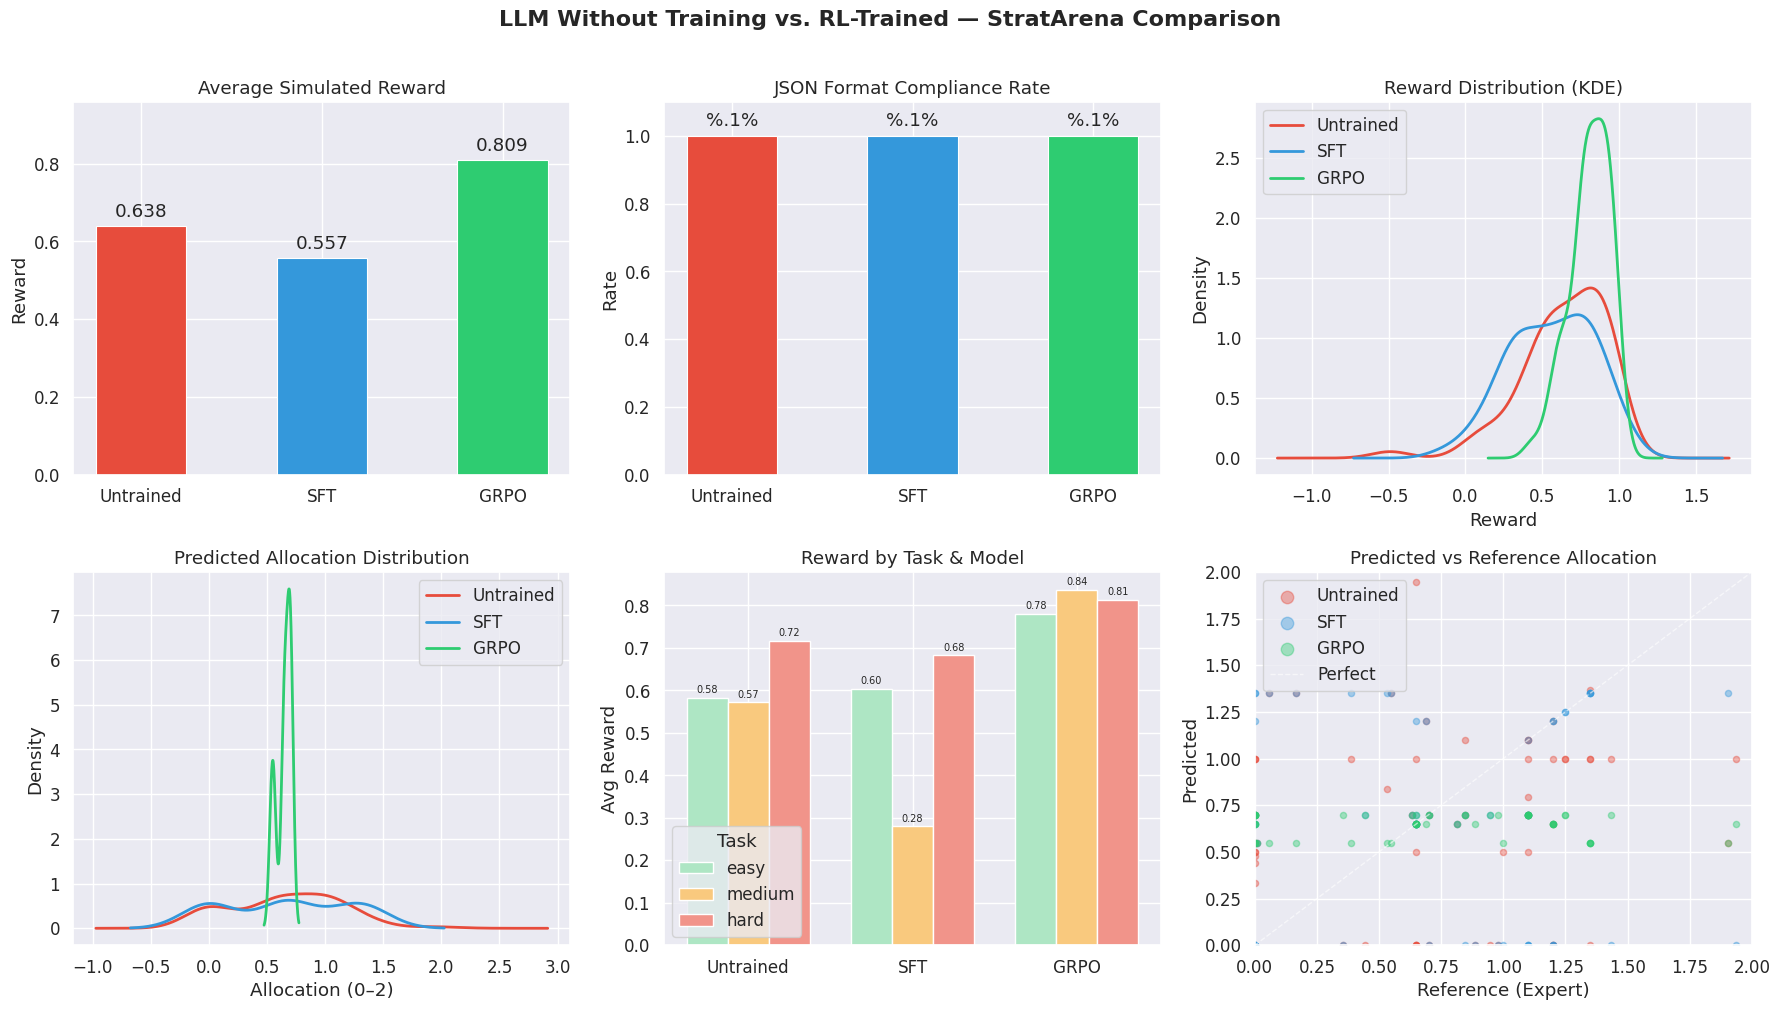

Fig 4 saved → comparison_main.png


In [28]:
# ── Fig 4: Head-to-head comparison (main plot) ────────────────────────────────
model_order = ['Untrained', 'SFT', 'GRPO']
palette     = {'Untrained': COLORS['untrained'], 'SFT': COLORS['sft'], 'GRPO': COLORS['grpo']}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('LLM Without Training vs. RL-Trained — StratArena Comparison',
             fontsize=16, fontweight='bold', y=1.01)


ax = axes[0, 0]
bars = ax.bar(
    model_order,
    [all_eval[all_eval['model'] == m]['simulated_reward'].mean() for m in model_order],
    color=[palette[m] for m in model_order], edgecolor='white', linewidth=0.8, width=0.5
)
ax.bar_label(bars, fmt='%.3f', padding=4)
ax.set_title('Average Simulated Reward'); ax.set_ylabel('Reward')
ax.set_ylim(min(0, bars[0].get_height() - 0.3), max(b.get_height() for b in bars) + 0.15)

ax = axes[0, 1]
rates = [all_eval[all_eval['model'] == m]['format_ok'].mean() for m in model_order]
bars = ax.bar(model_order, rates, color=[palette[m] for m in model_order],
              edgecolor='white', linewidth=0.8, width=0.5)
ax.bar_label(bars, fmt='%.1%', padding=4)
ax.set_ylim(0, 1.1); ax.set_title('JSON Format Compliance Rate'); ax.set_ylabel('Rate')

ax = axes[0, 2]
for m in model_order:
    subset = all_eval[all_eval['model'] == m]['simulated_reward'].dropna()
    subset.plot.kde(ax=ax, label=m, color=palette[m], linewidth=2)
ax.set_title('Reward Distribution (KDE)'); ax.set_xlabel('Reward'); ax.legend()

ax = axes[1, 0]
for m in model_order:
    subset = all_eval[all_eval['model'] == m]['predicted_alloc'].dropna()
    subset.plot.kde(ax=ax, label=m, color=palette[m], linewidth=2)
ax.set_title('Predicted Allocation Distribution'); ax.set_xlabel('Allocation (0–2)'); ax.legend()

ax = axes[1, 1]
task_reward = all_eval.groupby(['model', 'task'])['simulated_reward'].mean().reset_index()
task_colors_local = {'easy': '#aee6c4', 'medium': '#f9c97e', 'hard': '#f1948a'}
x = np.arange(len(model_order))
width = 0.25
for i, task in enumerate(['easy', 'medium', 'hard']):
    vals = [task_reward[(task_reward['model'] == m) & (task_reward['task'] == task)]['simulated_reward'].mean()
            for m in model_order]
    rects = ax.bar(x + i * width, vals, width, label=task,
                   color=task_colors_local[task], edgecolor='white')
    ax.bar_label(rects, fmt='%.2f', padding=2, fontsize=7)
ax.set_xticks(x + width)
ax.set_xticklabels(model_order)
ax.set_title('Reward by Task & Model'); ax.set_ylabel('Avg Reward'); ax.legend(title='Task')

ax = axes[1, 2]
for m in model_order:
    subset = all_eval[(all_eval['model'] == m) & all_eval['predicted_alloc'].notna()
                      & all_eval['reference_alloc'].notna()]
    ax.scatter(subset['reference_alloc'], subset['predicted_alloc'],
               alpha=0.4, s=20, label=m, color=palette[m])
lims = [0, 2]
ax.plot(lims, lims, 'w--', linewidth=1, alpha=0.6, label='Perfect')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_title('Predicted vs Reference Allocation')
ax.set_xlabel('Reference (Expert)'); ax.set_ylabel('Predicted'); ax.legend(markerscale=2)

plt.tight_layout()
plt.savefig('comparison_main.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 4 saved → comparison_main.png')

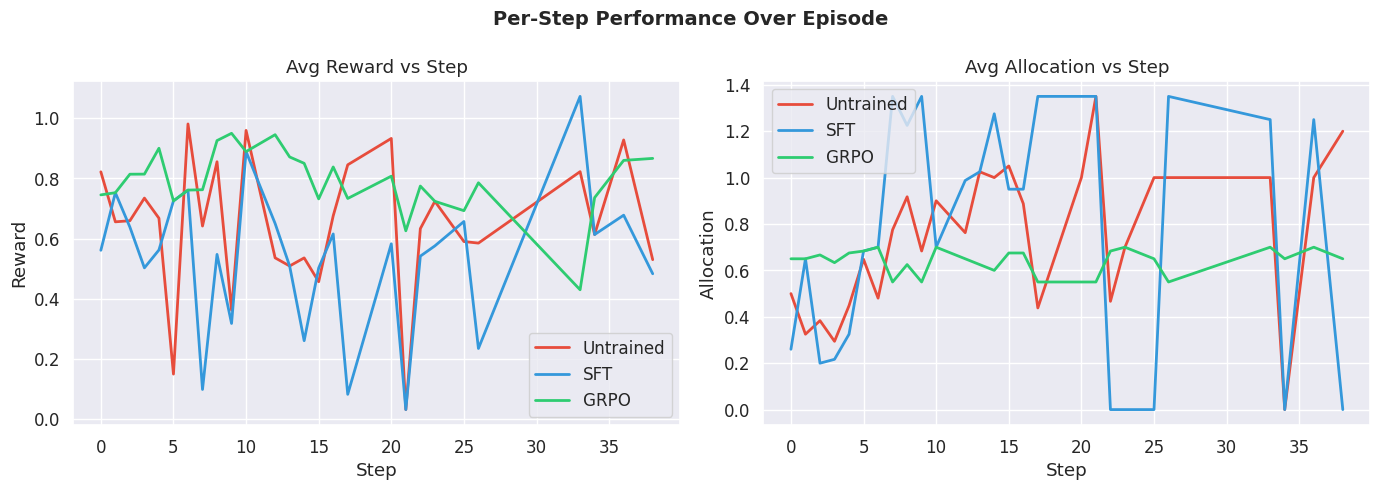

Fig 5 saved → per_step.png


In [29]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Per-Step Performance Over Episode', fontsize=14, fontweight='bold')

for m, color in palette.items():
    subset = all_eval[all_eval['model'] == m]
    step_r = subset.groupby('step')['simulated_reward'].mean()
    axes[0].plot(step_r.index, step_r.values, label=m, color=color, linewidth=2)
    step_a = subset.groupby('step')['predicted_alloc'].mean()
    axes[1].plot(step_a.index, step_a.values, label=m, color=color, linewidth=2)

axes[0].set_title('Avg Reward vs Step'); axes[0].set_xlabel('Step'); axes[0].set_ylabel('Reward'); axes[0].legend()
axes[1].set_title('Avg Allocation vs Step'); axes[1].set_xlabel('Step'); axes[1].set_ylabel('Allocation'); axes[1].legend()

plt.tight_layout()
plt.savefig('per_step.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 5 saved → per_step.png')

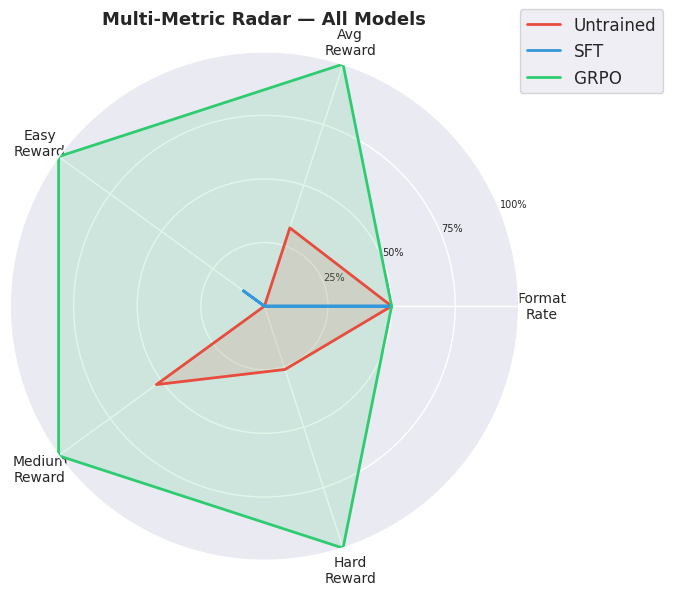

Fig 6 saved → radar_comparison.png


In [30]:
# ── Fig 6: Radar chart — multi-metric summary
from matplotlib.patches import FancyArrowPatch

def normalize_metric(vals, higher_better=True):
    lo, hi = min(vals), max(vals)
    if hi == lo:
        return [0.5] * len(vals)
    normed = [(v - lo) / (hi - lo) for v in vals]
    return normed if higher_better else [1 - n for n in normed]


metrics = ['Format\nRate', 'Avg\nReward', 'Easy\nReward', 'Medium\nReward', 'Hard\nReward']
N = len(metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

def get_radar_vals(model_name):
    sub = all_eval[all_eval['model'] == model_name]
    task_r = sub.groupby('task')['simulated_reward'].mean()
    return [
        sub['format_ok'].mean(),
        sub['simulated_reward'].mean(),
        task_r.get('easy', 0),
        task_r.get('medium', 0),
        task_r.get('hard', 0),
    ]

raw = {m: get_radar_vals(m) for m in model_order}
norm_cols = [normalize_metric([raw[m][i] for m in model_order]) for i in range(N)]
normed = {m: [norm_cols[i][j] for i in range(N)] for j, m in enumerate(model_order)}

fig = plt.figure(figsize=(7, 7))
ax  = fig.add_subplot(111, polar=True)

for m in model_order:
    vals = normed[m] + [normed[m][0]]
    ax.plot(angles, vals, color=palette[m], linewidth=2, label=m)
    ax.fill(angles, vals, color=palette[m], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, size=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], size=7)
ax.set_title('Multi-Metric Radar — All Models', pad=20, fontsize=13, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 6 saved → radar_comparison.png')

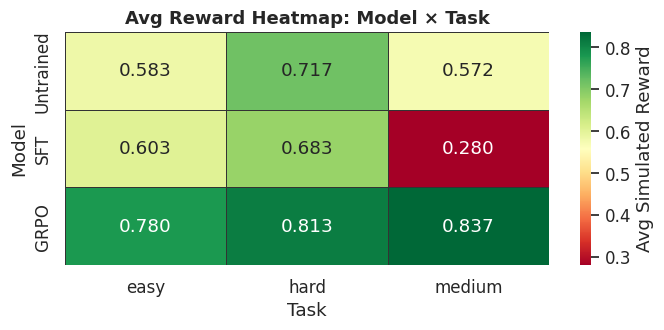

Fig 7 saved → reward_heatmap.png


In [31]:
# ── Fig 7: Improvement heatmap ────────────────────────────────────────────────
heat_data = all_eval.pivot_table(
    index='model', columns='task', values='simulated_reward', aggfunc='mean'
).reindex(model_order)

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, linecolor='#333', ax=ax,
            cbar_kws={'label': 'Avg Simulated Reward'})
ax.set_title('Avg Reward Heatmap: Model × Task', fontsize=13, fontweight='bold')
ax.set_xlabel('Task'); ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig('reward_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 7 saved → reward_heatmap.png')

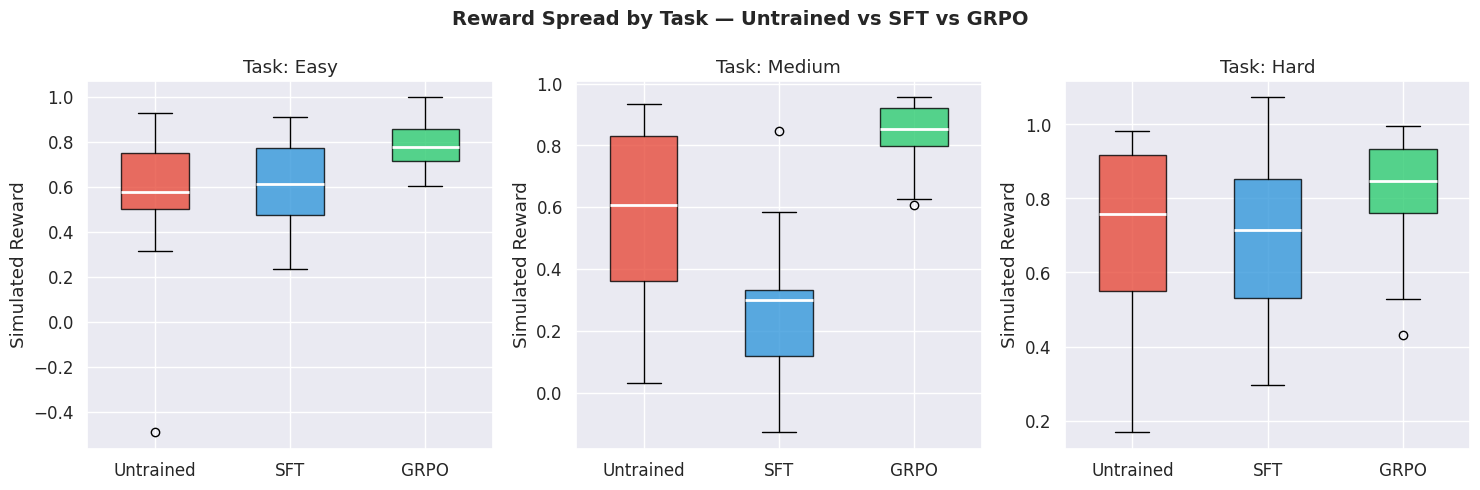

Fig 8 saved → boxplot_comparison.png


In [32]:
# ── Fig 8: Box plots — reward spread ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
fig.suptitle('Reward Spread by Task — Untrained vs SFT vs GRPO',
             fontsize=14, fontweight='bold')

for i, task in enumerate(['easy', 'medium', 'hard']):
    ax = axes[i]
    task_data = [all_eval[(all_eval['model'] == m) & (all_eval['task'] == task)]['simulated_reward'].dropna().values
                 for m in model_order]
    bp = ax.boxplot(task_data, patch_artist=True, widths=0.5,
                    medianprops={'color': 'white', 'linewidth': 2})
    for patch, m in zip(bp['boxes'], model_order):
        patch.set_facecolor(palette[m])
        patch.set_alpha(0.8)
    ax.set_xticklabels(model_order)
    ax.set_title(f'Task: {task.capitalize()}')
    ax.set_ylabel('Simulated Reward')

plt.tight_layout()
plt.savefig('boxplot_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 8 saved → boxplot_comparison.png')

---
## 8 · Final Summary Report

In [33]:
# ── Print final leaderboard ───────────────────────────────────────────────────
print('=' * 60)
print('          StratArena — Final Evaluation Leaderboard')
print('=' * 60)

leaderboard = []
for m in model_order:
    sub = all_eval[all_eval['model'] == m]
    leaderboard.append({
        'Model':       m,
        'Format Rate': f"{sub['format_ok'].mean():.1%}",
        'Avg Reward':  f"{sub['simulated_reward'].mean():.4f}",
        'Easy':        f"{sub[sub['task']=='easy']['simulated_reward'].mean():.4f}",
        'Medium':      f"{sub[sub['task']=='medium']['simulated_reward'].mean():.4f}",
        'Hard':        f"{sub[sub['task']=='hard']['simulated_reward'].mean():.4f}",
        'MAE vs Ref':  f"{(sub['predicted_alloc'] - sub['reference_alloc']).abs().mean():.4f}",
    })

lb_df = pd.DataFrame(leaderboard).set_index('Model')
print(lb_df.to_string())
print('=' * 60)

best = lb_df['Avg Reward'].astype(float).idxmax()
print(f'\n🏆 Best model: {best}')

          StratArena — Final Evaluation Leaderboard
          Format Rate Avg Reward    Easy  Medium    Hard MAE vs Ref
Model                                                              
Untrained      100.0%     0.6383  0.5831  0.5723  0.7167     0.5421
SFT            100.0%     0.5568  0.6032  0.2803  0.6825     0.5163
GRPO           100.0%     0.8087  0.7802  0.8370  0.8131     0.4173

🏆 Best model: GRPO


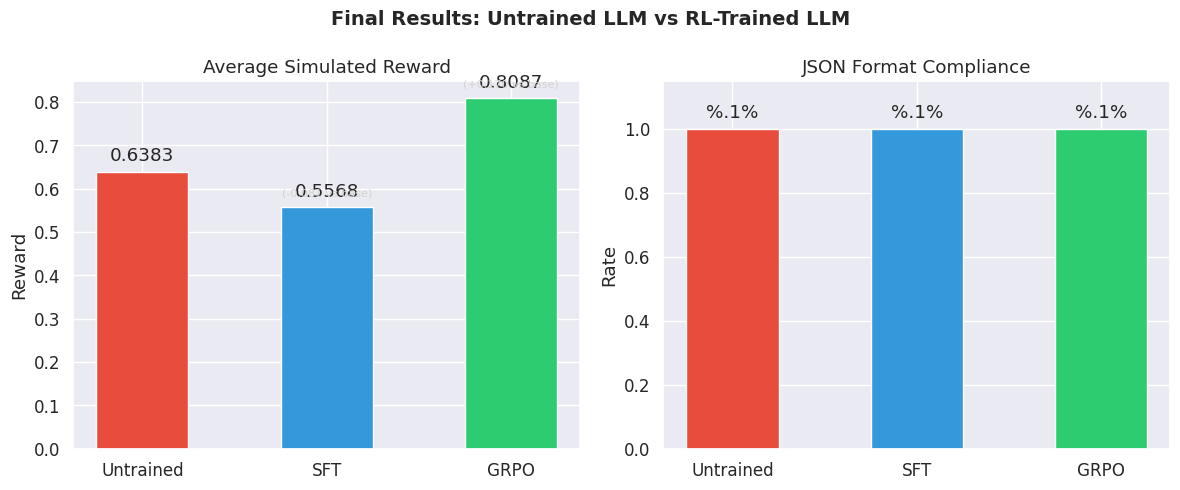

Fig 9 saved → final_summary.png

✅ All done! Check the saved PNG files for all plots.


In [34]:
# ── Fig 9: Final summary bar chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Final Results: Untrained LLM vs RL-Trained LLM', fontsize=14, fontweight='bold')

# Avg reward
ax = axes[0]
avg_rewards = [all_eval[all_eval['model'] == m]['simulated_reward'].mean() for m in model_order]
bars = ax.bar(model_order, avg_rewards, color=[palette[m] for m in model_order],
              edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=5)
baseline = avg_rewards[0]
for bar, val in zip(bars[1:], avg_rewards[1:]):
    delta = val - baseline
    sign  = '+' if delta >= 0 else ''
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f'({sign}{delta:.3f} vs base)',
            ha='center', va='bottom', fontsize=8, color='lightgray')
ax.set_title('Average Simulated Reward'); ax.set_ylabel('Reward')

# Format compliance
ax = axes[1]
fmt_rates = [all_eval[all_eval['model'] == m]['format_ok'].mean() for m in model_order]
bars = ax.bar(model_order, fmt_rates, color=[palette[m] for m in model_order],
              edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.1%', padding=5)
ax.set_ylim(0, 1.15); ax.set_title('JSON Format Compliance'); ax.set_ylabel('Rate')

plt.tight_layout()
plt.savefig('final_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 9 saved → final_summary.png')
print('\n✅ All done! Check the saved PNG files for all plots.')